# telecom_churn dataset
- telecom_churn_sample dataset is the integration of both the opencellid dataset and expresso dataset (2 million rows)


# OpenCellID and  Expresso integration
- OpenCellID  and  Expresso datasets do not share a direct key.
- Workflow for the integration:

 Geospatial aggregation of network quality dataset (OpenCellID)→ Region-level features → Join to customer dataset (Expresso)

 - OpenCellID = tower-level
- Expresso = customer-level (with REGION)
1. Convert tower lat/lon → Senegal administrative region
2. Aggregate network KPIs per region
3. Join to customer REGION

Achieve integration by joining Expresso customer dataset (~ 2,000,000-row ) with Senegal network quality features extracted from OpenCellID at three administrative levels:

  Level  | Source          | Granularity
  -------|-----------------|-----------------------------
  ADM1   | GADM GeoPackage | 14 Regions
  ADM2   | GADM GeoPackage | 45 Departments
  ADM3   | GADM GeoPackage | 123 Arrondissements

# Phase 1 Convert OpencelliD tower lat/lon to Senegal administrativr region


# Step 1 Mount Google Drive

**Authorize access when prompted.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2  Install and import libraries
- Core  
  - os:managing  file paths, environment variables, and directory structures
  - time: handling time-related tasks, such as measuring the execution duration of your data processing scripts.
  - json: parsing, encoding, and manipulating data in JavaScript Object Notation (JSON) format.
  - requests: interacting with web APIs.
  - numpy: computing multi-dimensional array operations.
  - pandas: manipulating structured data
  - matplotlib: creating static, animated, and interactive visualizations

- Scaling
  - dask: data processing by distributing large datasets across multiple partitions and executing computations in parallel
    - dask.diagnostics.ProgressBar: visual rendering of the progress of parallel computations, helping you monitor long-running Dask tasks
  - pyarrow: providing a high-performance interface for in-memory columnar data using for Apache Arrow

- Geospatial
  - geopandas: allow spatial operations on geometric types for geographic data
  - shapely: planar geometric objects like points, lines, and polygons.
  - pyproj: performing cartographic transformations and geodetic computations to convert coordinates between different reference systems.
  - folium: interactive high-quality web maps.
  - fiona: reading and writing vector geospatial data formats (like Shapefiles, GeoJSON, and GeoPackages)


- Spatial Join Optimization
  - rtree: indexing library to speeds up spatial queries and joins by organizing geometries into a hierarchical tree structure.

- Formatting
  - rich: renders rich text, including colors, tables, and syntax-highlighted JSON

In [ ]:
# Uncomment on first run in a fresh Colab session
# !pip install requests numpy pandas matplotlib geopandas shapely pyproj rtree folium rich "dask[complete]" fiona

In [ ]:
import os
import gc
import time
import json
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dask.dataframe as dd
from dask.diagnostics import ProgressBar

import geopandas as gpd
from shapely.geometry import Point
import folium
from folium.plugins import GroupedLayerControl
import fiona
from   rich import print as rprint

# view all columns in a pandas DataFrame
pd.set_option("display.max_columns", None)

# Step 3 Define File Paths




In [ ]:
# Base Path
BASE = "/path/to/datasets"

# OpenCellID Data
opencellid_file              = f"{BASE}/opencellid/opencellid_senegal_90d.csv"

# Expresso Data
expresso_file                = f"{BASE}/expresso/expresso.csv"

# Geospatial Data
gadm_gpkg_file               = f"{BASE}/telecom_churn/gadm41_SEN.gpkg"

# Processed Telecom Churn Data
telecom_churn_file = f"{BASE}/telecom_churn/telecom_churn.csv"

# Step 4 Obtain Senegal administrative boundary shapefiles
> Download Ready-Made Senegal Administrative Boundaries as GADM GeoPackage  

### Global Administrative Database (GADM)
- GADM is the Database of Global Administrative Areas that provide a high-resolution database of country administrative areas

- GADM provides multi-level administrative shapefiles:

  - Level 0 → Country
  - Level 1 → Regions
  - Level 2 → Departments
  - Level 3 → Arrondissements

![](https://geodata.ucdavis.edu/gadm/gadm4.1/png/SEN_adm.png)

> Senegal boundaries here:

https://gadm.org/download_country.html

### Senegal Admistrative Levels

| Country | Region | Department |Arrondissement |
| :--- | :--- | :--- |:--- |
| Senegal | 14 regions | 45 department |123 arrondissement |
| ![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e1/Senegal%2C_administrative_divisions_in_colour_2.svg/500px-Senegal%2C_administrative_divisions_in_colour_2.svg.png) | ![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Senegal%2C_administrative_divisions_-_en_-_monochrome.svg/500px-Senegal%2C_administrative_divisions_-_en_-_monochrome.svg.png) |![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e1/Senegal%2C_administrative_divisions_in_colour_2.svg/960px-Senegal%2C_administrative_divisions_in_colour_2.svg.png) |![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Senegal_arrondissements.png/500px-Senegal_arrondissements.png) |

| Country | Region | Department |Arrondissement |
| :--- | :--- | :--- |:--- |
| ADM0 | ADM1 | ADM2 |ADM3 |
| ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM0/geoBoundaries-SEN-ADM0-PREVIEW.png) | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM1/geoBoundaries-SEN-ADM1-PREVIEW.png) |![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM2/geoBoundaries-SEN-ADM2-PREVIEW.png) |![](https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/SEN/ADM3/geoBoundaries-SEN-ADM3-PREVIEW.png) |

| Admin | Localname | Preview |
| :--- | :--- | :--- |
| ADM0 | Country | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM0/geoBoundaries-SEN-ADM0-PREVIEW.png)|

| Admin | Localname | Preview |
| :--- | :--- | :--- |
| ADM1 | Region | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM1/geoBoundaries-SEN-ADM1-PREVIEW.png)|

| Admin | Localname | Preview |
| :--- | :--- | :--- |
| ADM2 | Department | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM2/geoBoundaries-SEN-ADM2-PREVIEW.png)|

| Level | Localname | Preview |
| :--- | :--- | :--- |
| ADM3 | Arrondissement | ![](https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/SEN/ADM3/geoBoundaries-SEN-ADM3-PREVIEW.png)|



In [ ]:
# GADM v4.1 direct download — Senegal GeoPackage
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_SEN.gpkg"

def download_file(url: str, dest: str, label: str, retries: int = 3) -> bool:
    """Stream-download with retry; skip if file already cached."""
    if os.path.exists(dest):
        mb = os.path.getsize(dest) / 1024 / 1024
        print(f"{label} — already cached ({mb:.1f} MB), skipping")
        return True
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    for attempt in range(1, retries + 1):
        try:
            print(f"{label} — attempt {attempt}/{retries} …")
            r = requests.get(url, stream=True, timeout=180)
            if r.status_code == 200:
                with open(dest, "wb") as f:
                    for chunk in r.iter_content(chunk_size=256 * 1024):
                        f.write(chunk)
                mb = os.path.getsize(dest) / 1024 / 1024
                print(f"{label} — saved ({mb:.1f} MB)")
                return True
            print(f"HTTP {r.status_code}")
        except Exception as exc:
            print(f"Attempt {attempt} failed: {exc}")
        time.sleep(3)
    print(f"Download failed. Get the file manually:\n     {url}")
    return False

print("Checking GADM GeoPackage …")
download_file(GADM_URL, gadm_gpkg_file, "GADM SEN v4.1 GeoPackage")

Checking GADM GeoPackage …
GADM SEN v4.1 GeoPackage — already cached (6.1 MB), skipping


True

# Step 5 Inspect & Load GADM Layers

In [ ]:
print("Available layers in GeoPackage:")
layers = fiona.listlayers(gadm_gpkg_file)
rprint(layers)

Available layers in GeoPackage:


['ADM_ADM_0', 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3', 'ADM_ADM_4']

In [ ]:
# Load GADM Layers
def load_gadm_layer(gpkg: str, layer: str, label: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(gpkg, layer=layer).to_crs("EPSG:4326")
    print(f"\n  {label}: {len(gdf)} polygons | CRS: {gdf.crs}")
    print(f"    Columns: {list(gdf.columns)}")
    return gdf

gdf_regions         = load_gadm_layer(gadm_gpkg_file, "ADM_ADM_1", "ADM1 Regions")
gdf_departments     = load_gadm_layer(gadm_gpkg_file, "ADM_ADM_2", "ADM2 Departments")
gdf_arrondissements = load_gadm_layer(gadm_gpkg_file, "ADM_ADM_3", "ADM3 Arrondissements")

# GADM v4.1 stores names in NAME_1 / NAME_2 / NAME_3

REGION_COL         = "NAME_1"
DEPARTMENT_COL     = "NAME_2"
ARRONDISSEMENT_COL = "NAME_3"


  ADM1 Regions: 14 polygons | CRS: EPSG:4326
    Columns: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']

  ADM2 Departments: 45 polygons | CRS: EPSG:4326
    Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']

  ADM3 Arrondissements: 123 polygons | CRS: EPSG:4326
    Columns: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']


### Coordinate Reference System (CRS)
>refers to the way in which spatial data that represent the earth’s surface (which is round / 3 dimensional) are flattened so that you can “Draw” them on a 2-dimensional surface.

>![](https://earthdatascience.org/images/courses/earth-analytics/spatial-data/geographic-origin.png)

>A CRS defines the translation between a location on the round earth and that same location, on a flattened, 2 dimensional coordinate system. Source: [http://ayresriverblog.com](http://ayresriverblog.com)

> [Earth analytics Course: Coordinate Reference System and Spatial Projection](https://earthdatascience.org/courses/earth-analytics/spatial-data-r/intro-to-coordinate-reference-systems/)

- It is mathematical framework that defines how the three-dimensional, curved surface of the Earth is represented on a two-dimensional map using specific coordinates.

>EPSG:4326 is the most widely used Coordinate Reference System (CRS) in the world, serving as the default for GPS, web mapping (like Google Maps), and most raw spatial data formats (GeoJSON, CSV).

> to ensure the spatial data uses the global standard for latitude and longitude, we  need to convert the coordinates of the polygons into WGS84 and perform a Coordinate Reference System (CRS) transformation

> WGS84 is the standard system used by GPS and web maps (like Google Maps or Folium).

In [ ]:
# Check CRS
print("CRS:", gdf_regions.crs)

CRS: EPSG:4326


In [ ]:
# Eensure the spatial data uses the global standard for latitude and longitude.
gdf_regions = gdf_regions.to_crs("EPSG:4326")

In [ ]:
# Check region name column
gdf_regions.columns

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')

In [ ]:
rprint(sorted(gdf_regions[REGION_COL].tolist()))

[
    'Dakar',
    'Diourbel',
    'Fatick',
    'Kaffrine',
    'Kaolack',
    'Kolda',
    'Kédougou',
    'Louga',
    'Matam',
    'Saint-Louis',
    'Sédhiou',
    'Tambacounda',
    'Thiès',
    'Ziguinchor'
]

<Axes: >

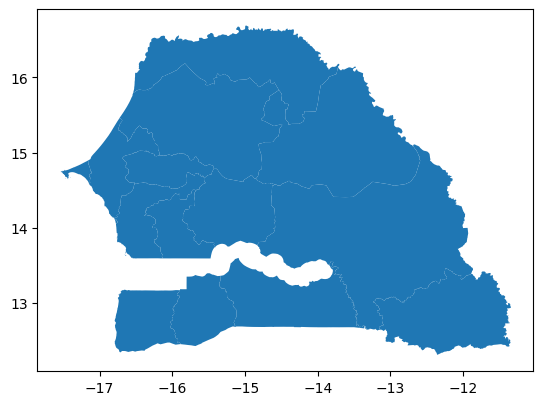

In [ ]:
# View the actual map shapes
gdf_regions.plot()

In [ ]:
gdf_regions.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,SEN.1_1,SEN,Senegal,Dakar,Cap Vert|Dacar,NA,Région,Region,1,SN.DK,SN-DK,"MULTIPOLYGON (((-17.46764 14.64874, -17.46764 ..."
1,SEN.2_1,SEN,Senegal,Diourbel,NA,NA,Région,Region,3,SN.DB,SN-DB,"MULTIPOLYGON (((-16.04326 14.555, -16.04513 14..."
2,SEN.3_1,SEN,Senegal,Fatick,NA,NA,Région,Region,9,SN.FK,SN-FK,"MULTIPOLYGON (((-16.65347 13.64736, -16.65347 ..."
3,SEN.4_1,SEN,Senegal,Kaffrine,NA,NA,Région,Region,12,SN.KF,SN-KA,"MULTIPOLYGON (((-15.39492 13.75729, -15.39724 ..."
4,SEN.5_1,SEN,Senegal,Kaolack,NA,NA,Région,Region,6,SN.KC,SN-KL,"MULTIPOLYGON (((-15.99889 13.59169, -15.9991 1..."


In [ ]:
# Create pretty interactive map for Senegal regions
m = gdf_regions.explore(
    column="NAME_1",  # Color polygons by region name
    cmap="Set2",         # color palette
    tooltip="NAME_1", # Show name when hovering
    popup=True           # Show all properties when clicking
)
m

# Step 6 Load OpenCellID &  Build Tower GeoDataFrame

opencellid_senegal_90d provides geographic coordinates and network information for cell tower locations across Senegal with 90 days observation window (May-August 2021) to match Expresso dataset

Data Source

- [Kaggle dataset: Cell Towers Worldwide: Location Data by Continent](
https://www.kaggle.com/datasets/zakariaeyoussefi/cell-towers-worldwide-location-data-by-continent)

It includes the following columns:

- Radio: The generation of broadband cellular network technology (e.g., LTE, GSM).
- MCC: Mobile Country Code, a unique identifier for each country in the mobile network.
- MNC: Mobile Network Code, identifying the mobile network within a country.
- LAC: Location Area Code, Tracking Area Code, or Network Identifier.
- CID: Unique identifier for each Base Transceiver Station (BTS) or sector.
- Longitude: Geographic coordinate specifying the east-west position.
- Latitude: Geographic coordinate specifying the north-south position.
- Range: Approximate area within which the cell coverage extends (in meters).
- Samples: Number of measures processed to derive the data point.
- Changeable: Indicates if the cell location was determined through sample processing (1) or directly obtained from the telecom firm (0).
- Created: Timestamp indicating when the cell was first added to the database (UNIX format).
- Updated: Timestamp indicating when the cell was last seen or updated in the database (UNIX format).
- AverageSignal: Represents the averaged signal strength of the cell location.
- Country: The country of the cell tower.
- Network: The company that owns the cell tower.
- Continent: The continent of the cell tower.
- Created_date: Date when the cell was first added to the database
- Updated_date: Date when the cell was last seen or updated in the database


In [ ]:
print("Loading OpenCellID …")

opencellid = pd.read_csv(opencellid_file)
print(f"Towers loaded: {len(opencellid):,}")

Loading OpenCellID …
Towers loaded: 3,267


In [ ]:
opencellid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3267 entries, 0 to 3266
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   radio          3267 non-null   object 
 1   MCC            3267 non-null   int64  
 2   MNC            3267 non-null   int64  
 3   TAC            3267 non-null   int64  
 4   CID            3267 non-null   int64  
 5   unit           3267 non-null   int64  
 6   LON            3267 non-null   float64
 7   LAT            3267 non-null   float64
 8   RANGE          3267 non-null   float64
 9   SAM            3267 non-null   int64  
 10  changeable     3267 non-null   int64  
 11  created        3267 non-null   int64  
 12  updated        3267 non-null   int64  
 13  averageSignal  3267 non-null   float64
 14  Country        3267 non-null   object 
 15  Network        3267 non-null   object 
 16  Continent      3267 non-null   object 
 17  created_date   3267 non-null   object 
 18  updated_

In [ ]:
opencellid.head()

,radio,MCC,MNC,TAC,CID,unit,LON,LAT,RANGE,SAM,changeable,created,updated,averageSignal,Country,Network,Continent,created_date,updated_date
0,GSM,608,3,801,60053,0,-14.943466,12.890396,1000.0,5,1,1459813076,1460884030,0.0,Senegal,Expresso,Africa,2016-04-04 23:37:56,2016-04-17 09:07:10
1,GSM,608,3,401,43013,0,-16.500776,14.361879,2792.0,2,1,1351194533,1456970224,0.0,Senegal,Expresso,Africa,2012-10-25 19:48:53,2016-03-03 01:57:04
2,GSM,608,3,401,43011,0,-16.496656,14.361879,3218.0,2,1,1351194533,1456970224,0.0,Senegal,Expresso,Africa,2012-10-25 19:48:53,2016-03-03 01:57:04
3,GSM,608,3,701,57042,0,-14.722878,13.998784,56823.0,5,1,1351272426,1478774472,0.0,Senegal,Expresso,Africa,2012-10-26 17:27:06,2016-11-10 10:41:12
4,GSM,608,3,701,57045,0,-14.593620,13.982508,3757.0,4,1,1351272426,1472278594,0.0,Senegal,Expresso,Africa,2012-10-26 17:27:06,2016-08-27 06:16:34


### Create Point objects
- Shapely Point object: geometry type that represents a single coordinate
- Create a sequence of Shapely Point objects by pairing longitude (lon) as ($x$) and latitude (lat) as ($y$) coordinates from the two separate columns opencellid['lon']and opencellid['lat'] to represent specific geographic locations.


In [ ]:
# Create a sequence of Shapely Point objects
geometry = [Point(xy) for xy in zip(opencellid['LON'], opencellid['LAT'])]

In [ ]:
geometry[:5]

[<POINT (-14.943 12.89)>,
 <POINT (-16.501 14.362)>,
 <POINT (-16.497 14.362)>,
 <POINT (-14.723 13.999)>,
 <POINT (-14.594 13.983)>]

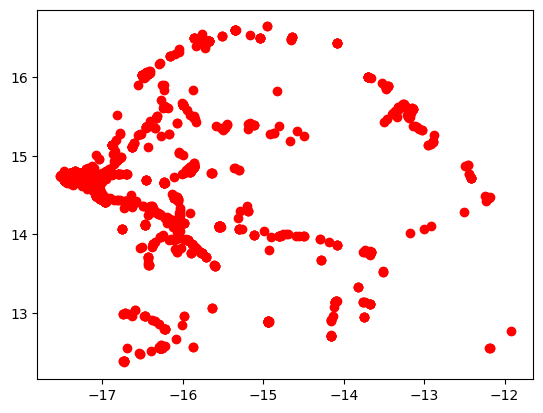

In [ ]:
# Visualize Shapely Point objects

# Extract x and y coordinates
x = [p.x for p in geometry]
y = [p.y for p in geometry]

# Plot x and y
plt.scatter(x, y, color='red')
plt.show()

In [ ]:
# Build Tower GeoDataFrame
gdf_cells = gpd.GeoDataFrame(
    opencellid,
    geometry=geometry,
    crs="EPSG:4326"
)


# Phase 2 Aggregate Network to Region Level


# Step 7 Create Spatial Utility Functions
- spatial_join_towers()
  - Point-in-polygon spatial join.

- compute_network_kpis()
  - calculate netwok features per zone (region/department/arrondissement)
  - tower_count = number of cell towers in zone
  - avg_range = mean tower range (m)
  - avg_samples = mean measurement samples
  - avg_signal = mean signal strength (dBm)
  - coverage_index = tower_count * avg_range  (reach proxy)
  - signal_strength_index = avg_signal / avg_samples (quality proxy)
  - network_quality_score is composite score calculated as:
```
network_quality_score = (
    0.4 * avg_signal +
    0.3 * tower_count +
    0.3 * avg_samples
)
```


In [ ]:
def spatial_join_towers(gdf_towers:  gpd.GeoDataFrame,
                        gdf_poly:    gpd.GeoDataFrame,
                        poly_col:    str,
                        out_col:     str) -> gpd.GeoDataFrame:
    """
    Point-in-polygon spatial join.
    Renames `poly_col` → `out_col`, removes `index_right`.
    """
    result = gpd.sjoin(
        gdf_towers,
        gdf_poly[[poly_col, "geometry"]],
        how="left",
        predicate="within"
    ).drop(columns=["index_right"], errors="ignore")
    return result.rename(columns={poly_col: out_col})

In [ ]:
def compute_network_kpis(gdf:        gpd.GeoDataFrame,
                         group_cols: list,
                         prefix:     str) -> pd.DataFrame:
    """
    Aggregate tower-level data to admin-zone KPIs.
    All output columns are prefixed with `prefix_`.

    KPIs computed
    -------------
    {prefix}_tower_count            — number of cell towers in zone
    {prefix}_avg_range              — mean tower range (m)
    {prefix}_avg_samples            — mean measurement samples
    {prefix}_avg_signal             — mean signal strength (dBm)
    {prefix}_coverage_index         — tower_count × avg_range  (reach proxy)
    {prefix}_signal_strength_index  — avg_signal / avg_samples (quality proxy)
    {prefix}_network_quality_score  — composite 0–1 score
    """
    agg = (
        gdf.groupby(group_cols)
        .agg(
            **{f"{prefix}_tower_count": ("CID",          "count")},
            **{f"{prefix}_avg_range":   ("RANGE",         "mean")},
            **{f"{prefix}_avg_samples": ("SAM",       "mean")},
            **{f"{prefix}_avg_signal":  ("averageSignal", "mean")},
        )
        .reset_index()
    )
    agg[f"{prefix}_coverage_index"] = (
        agg[f"{prefix}_tower_count"] * agg[f"{prefix}_avg_range"]
    )
    agg[f"{prefix}_signal_strength_index"] = (
        agg[f"{prefix}_avg_signal"] /
        agg[f"{prefix}_avg_samples"].replace(0, np.nan)
    )
    agg[f"{prefix}_network_quality_score"] = (
        0.4 * agg[f"{prefix}_signal_strength_index"] +
        0.3 * agg[f"{prefix}_tower_count"] +
        0.3 * agg[f"{prefix}_avg_samples"]
    )
    return agg

# Step 8 Region (ADM1) KPIs

In [ ]:
print("── Region (ADM1) ──")

gdf_towers_region = spatial_join_towers(
    gdf_cells, gdf_regions, REGION_COL, "REGION"
)
print("Tower distribution by region:")
print(gdf_towers_region["REGION"].value_counts(dropna=False).to_string())

── Region (ADM1) ──
Tower distribution by region:
REGION
Dakar          1771
Thiès           346
Kaolack         206
Saint-Louis     184
Diourbel        149
Ziguinchor      108
Louga            94
Tambacounda      75
Fatick           73
Matam            70
Kolda            64
NaN              62
Kaffrine         56
Sédhiou           5
Kédougou          4


In [ ]:
network_region_kpis = compute_network_kpis(gdf_towers_region, ["REGION"], "region")
network_region_kpis["REGION"] = network_region_kpis["REGION"].str.strip().str.upper()
print(network_region_kpis.to_string())

         REGION  region_tower_count  region_avg_range  region_avg_samples  region_avg_signal  region_coverage_index  region_signal_strength_index  region_network_quality_score
0         DAKAR                1771       1347.316206            6.294184                0.0              2386097.0                           0.0                    533.188255
1      DIOURBEL                 149       1025.973154            1.664430                0.0               152870.0                           0.0                     45.199329
2        FATICK                  73       2626.958904            2.136986                0.0               191768.0                           0.0                     22.541096
3      KAFFRINE                  56      10797.678571            2.875000                0.0               604670.0                           0.0                     17.662500
4       KAOLACK                 206       2353.553398            2.747573                0.0               484832.0     

# Step 9 Department (ADM2) KPIs

In [ ]:
print("── Department (ADM2) ──")

gdf_towers_dept = spatial_join_towers(gdf_cells,      gdf_departments, DEPARTMENT_COL, "department")
gdf_towers_dept = spatial_join_towers(gdf_towers_dept, gdf_regions,    REGION_COL,     "REGION")

print("Top region/department combos by tower count:")
print(gdf_towers_dept[["REGION","department"]].value_counts(dropna=False).head(10).to_string())

── Department (ADM2) ──
Top region/department combos by tower count:
REGION       department 
Dakar        Dakar          1120
             Pikine          331
             Rufisque        199
Kaolack      Kaolack         154
Thiès        Thiès           154
             Mbour           130
Diourbel     Mbacké          128
Dakar        Guédiawaye      121
Saint-Louis  Saint-Louis     117
Ziguinchor   Ziguinchor       64


In [ ]:
network_department_kpis = compute_network_kpis(
    gdf_towers_dept, ["REGION","department"], "department"
)
network_department_kpis["REGION"] = network_department_kpis["REGION"].str.strip().str.upper()

# Roll up department KPIs to region level (needed for customer-level join)
dept_kpis_per_region = (
    network_department_kpis
    .groupby("REGION")
    .agg(
        department_coverage_index       =("department_coverage_index",        "sum"),
        department_signal_strength_index=("department_signal_strength_index", "mean"),
        department_network_quality_score=("department_network_quality_score", "mean")
    )
    .reset_index()
)
print(dept_kpis_per_region.to_string())


         REGION  department_coverage_index  department_signal_strength_index  department_network_quality_score
0         DAKAR                  2386097.0                               0.0                        134.914073
1      DIOURBEL                   152870.0                               0.0                         15.418594
2        FATICK                   191768.0                               0.0                          7.923556
3      KAFFRINE                   604670.0                               0.0                          6.374140
4       KAOLACK                   484832.0                               0.0                         21.205722
5         KOLDA                   103986.0                               0.0                         10.823701
6      KÉDOUGOU                     4956.0                               0.0                          1.050000
7         LOUGA                   399897.0                               0.0                         10.543254
8

# Step 10 Arrondissement (ADM3) KPIs

In [ ]:
print("── Arrondissement (ADM3) ──")

gdf_towers_arr = spatial_join_towers(gdf_cells,      gdf_arrondissements, ARRONDISSEMENT_COL, "arrondissement")
gdf_towers_arr = spatial_join_towers(gdf_towers_arr, gdf_regions,         REGION_COL,         "REGION")

print("Top region/arrondissement combos by tower count:")
print(gdf_towers_arr[["REGION","arrondissement"]].value_counts(dropna=False).head(10).to_string())

── Arrondissement (ADM3) ──
Top region/arrondissement combos by tower count:
REGION       arrondissement     
Dakar        Almadies               318
             Dakar Plateau          297
             Grand Dakar            261
             Parcelles Assainies    244
             Thiaroye               154
Kaolack      Koumbal                124
Diourbel     Ndame                  123
Dakar        Guediawaye             121
             Bambilor               118
Saint-Louis  Rao                    117


In [ ]:
network_arrondissement_kpis = compute_network_kpis(
    gdf_towers_arr, ["REGION","arrondissement"], "arrondissement"
)
network_arrondissement_kpis["REGION"] = (
    network_arrondissement_kpis["REGION"].str.strip().str.upper()
)

# Roll up arrondissement KPIs to region level
arr_kpis_per_region = (
    network_arrondissement_kpis
    .groupby("REGION")
    .agg(
        arr_coverage_index       =("arrondissement_coverage_index",        "sum"),
        arr_signal_strength_index=("arrondissement_signal_strength_index", "mean"),
        arr_network_quality_score=("arrondissement_network_quality_score", "mean")
    )
    .reset_index()
)
print(arr_kpis_per_region.to_string())

         REGION  arr_coverage_index  arr_signal_strength_index  arr_network_quality_score
0         DAKAR           2386097.0                        0.0                  55.106100
1      DIOURBEL            152870.0                        0.0                  11.770244
2        FATICK            191768.0                        0.0                   3.743333
3      KAFFRINE            604670.0                        0.0                   4.005514
4       KAOLACK            484832.0                        0.0                   8.279980
5         KOLDA            103986.0                        0.0                   4.777321
6      KÉDOUGOU              4956.0                        0.0                   1.050000
7         LOUGA            399897.0                        0.0                   4.315221
8         MATAM            229312.0                        0.0                   9.799697
9   SAINT-LOUIS            421034.0                        0.0                  13.713084
10      SÉ

# Phase 3 Join Network KPIs to customer REGION


# Step 11 Load Expresso Dataset with Dask

>**Expresso** is an African telecommunications company that provides customers with airtime and mobile data bundles.

The data from Expresso churn prediction challenge on Zindi describes 2.5 million Expresso clients in Senegal to  predict the likelihood of each Expresso customer “churning,” i.e. becoming inactive and not making any transactions for 90 days.

>[Dataset for the Expresso churn prediction challenge](https://zindi.africa/competitions/expresso-churn-prediction/data)

The Expresso dataset is representing customer behavior, service usage patterns, and revenue characteristics. Each row corresponds to a unique Expresso customer.

The dataset consists of customer-level variables describing recharge behavior, revenue contribution, usage activity, subscription patterns, geographic location, and service engagement metrics.

expresso dataset contains the train.csv file that  includes both numerical and categor­ ical features with 2,154,048 rows.

The target is a column called CHURN that indicates if a client churned or did not churn..

It provides the following:
- user_id
- REGION:		the location of each client
- TENURE:		duration in the network
- MONTANT:		top-up amount
- FREQUENCE_RECH:	number of times the customer refilled
- REVENUE:	revenu  client	monthly income of each client
- ARPU_SEGMENT:	income over 90 days / 3
- FREQUENCE:	number of times the client has made an income
- DATA_VOLUME:	number of connections
- ON_NET:	 	inter expresso call
- ORANGE:		call to orange
- TIGO:	  	call to Tigo
- ZONE1:		call to zones1
- ZONE2:		call to zones2
- MRG:	 	a client who is going
- REGULARITY:	number of times the client is active for 90 days
- TOP_PACK:	the most active packs
- FREQ_TOP_PACK:	number of times the client has activated the top pack packages
- CHURN:		variable to predict - Target


In [ ]:
# Define Data Types

dtypes = {
    "user_id": "object",          # keep as string (unique id)
    "REGION": "category",         # small set of regions
    "TENURE": "category",         # text categories like "K > 24 month"
    "MONTANT": "float32",
    "FREQUENCE_RECH": "float32",
    "REVENUE": "float32",
    "ARPU_SEGMENT": "float32",
    "FREQUENCE": "float32",
    "DATA_VOLUME": "float32",
    "ON_NET": "float32",
    "ORANGE": "float32",
    "TIGO": "float32",
    "ZONE1": "float32",
    "ZONE2": "float32",
    "MRG": "category",            # YES / NO
    "REGULARITY": "int16",
    "TOP_PACK": "category",       # limited unique values
    "FREQ_TOP_PACK": "float32",
    "CHURN": "int8"               # binary target
}

In [ ]:
# Define Columns to Load
columns = list(dtypes.keys())
columns


['user_id',
 'REGION',
 'TENURE',
 'MONTANT',
 'FREQUENCE_RECH',
 'REVENUE',
 'ARPU_SEGMENT',
 'FREQUENCE',
 'DATA_VOLUME',
 'ON_NET',
 'ORANGE',
 'TIGO',
 'ZONE1',
 'ZONE2',
 'MRG',
 'REGULARITY',
 'TOP_PACK',
 'FREQ_TOP_PACK',
 'CHURN']

In [ ]:
# Load Dataset With Dask
print("Loading Expresso dataset with Dask …")

ddf = dd.read_csv(
    expresso_file,
    usecols=columns,
    dtype=dtypes,
    blocksize="32MB",      # smaller partitions for safer RAM usage
    assume_missing=True
)

print(f"Dask partitions : {ddf.npartitions}")
print(f"Columns         : {list(ddf.columns)}")

Loading Expresso dataset with Dask …
Dask partitions : 8
Columns         : ['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK', 'CHURN']


In [ ]:
# Normalise REGION before categorize so the cleaned strings become the category labels
ddf["REGION"] = ddf["REGION"].str.strip().str.upper()

In [ ]:
# Categorize all string/categorical columns
CAT_COLS = ["REGION", "TENURE", "MRG", "TOP_PACK"]
ddf = ddf.categorize(columns=CAT_COLS)

In [ ]:
# Check Estimated Memory Usage
print("Estimated memory usage:")

print(
    ddf.memory_usage(deep=True)
    .compute()
    .sum() / 1e6,
    "MB"
)

Estimated memory usage:
224.152224 MB


# Step 12 Merge Network KPI Tables to Expresso with Dask

- All Network KPI tables are small pandas DataFrames
- Dask broadcasts them to every partition — no expensive shuffle needed.


In [ ]:
# Align REGION categories in the small pandas KPI tables to match Dask ddf.

region_cats = ddf["REGION"].cat.categories  # Index of known region strings
region_cats

Index(['DAKAR', 'DIOURBEL', 'FATICK', 'KAFFRINE', 'KAOLACK', 'KEDOUGOU',
       'KOLDA', 'LOUGA', 'MATAM', 'SAINT-LOUIS', 'SEDHIOU', 'TAMBACOUNDA',
       'THIES', 'ZIGUINCHOR'],
      dtype='object', name='REGION')

In [ ]:
for kpi_df in [network_region_kpis, dept_kpis_per_region, arr_kpis_per_region]:
    kpi_df["REGION"] = pd.Categorical(
        kpi_df["REGION"].str.strip().str.upper(),
        categories=region_cats
    )

In [ ]:
print("Building Dask merge graph …")

# Deduplicate each KPI table before the merge
network_region_kpis = network_region_kpis.drop_duplicates(subset=["REGION"])
dept_kpis_per_region = dept_kpis_per_region.drop_duplicates(subset=["REGION"])
arr_kpis_per_region = arr_kpis_per_region.drop_duplicates(subset=["REGION"])

ddf = ddf.merge(network_region_kpis,   on="REGION", how="left")   # region KPIs
ddf = ddf.merge(dept_kpis_per_region,  on="REGION", how="left")   # department KPIs
ddf = ddf.merge(arr_kpis_per_region,   on="REGION", how="left")   # arrondissement KPIs


print(f"Graph Partitions: {ddf.npartitions}")

# Check the number of rows after the merge graph is built
total_rows = len(ddf)
print(f"Final row count: {total_rows:,}")

Building Dask merge graph …
Graph Partitions: 8
Final row count: 2,154,048


# Step 13 Compute Dask Graph → pandas Dataframe


In [ ]:
print("Computing … ")
with ProgressBar():
    telecom_churn = ddf.compute()

# Fix repeated partition indexes
telecom_churn = telecom_churn.reset_index(drop=True)

print(f"Computed shape : {telecom_churn.shape}")
print(f"Index range    : {telecom_churn.index.min()} → {telecom_churn.index.max()}")
print(f"Index unique   : {telecom_churn.index.is_unique}")

# Computing …
# [########################################] | 100% Completed | 13.55 s
# Computed shape : (2154048, 32)
# Index range    : 0 → 2154047
# Index unique   : True

Computing … 
[########################################] | 100% Completed | 13.55 s
Computed shape : (2154048, 32)
Index range    : 0 → 2154047
Index unique   : True


# Step 14 Column Selection & Shape

In [ ]:
# Normalise column names to lower-case
telecom_churn.columns = [c.lower() for c in telecom_churn.columns]

# Canonical column order for the final dataset
FINAL_COLS = [
    # ── Customer identifiers
    "user_id", "region",
    # ── Customer behaviour
    "tenure", "montant", "frequence_rech", "revenue", "arpu_segment",
    "frequence", "data_volume", "on_net", "orange", "tigo",
    "zone1", "zone2", "mrg", "regularity", "top_pack", "freq_top_pack",
    # ── Region-level network KPIs  (ADM1)
    "region_tower_count", "region_avg_range", "region_avg_samples", "region_avg_signal",
    "region_coverage_index", "region_signal_strength_index", "region_network_quality_score",
    # ── Department-level network KPIs  (ADM2, aggregated to region)
    "department_signal_strength_index", "department_network_quality_score",
    "department_coverage_index",
    # ── Arrondissement-level network KPIs  (ADM3, aggregated to region)
    "arr_signal_strength_index", "arr_network_quality_score", "arr_coverage_index",
    # ── Target
    "churn",
]

existing = [c for c in FINAL_COLS if c in telecom_churn.columns]
missing  = [c for c in FINAL_COLS if c not in telecom_churn.columns]
if missing:
    print(f"Columns not found (check source files): {missing}")

telecom_churn = telecom_churn[existing]
print(f"Final shape  : {telecom_churn.shape}")
print(f"Columns ({len(existing)}): {existing}")

Final shape  : (2154048, 32)
Columns (32): ['user_id', 'region', 'tenure', 'montant', 'frequence_rech', 'revenue', 'arpu_segment', 'frequence', 'data_volume', 'on_net', 'orange', 'tigo', 'zone1', 'zone2', 'mrg', 'regularity', 'top_pack', 'freq_top_pack', 'region_tower_count', 'region_avg_range', 'region_avg_samples', 'region_avg_signal', 'region_coverage_index', 'region_signal_strength_index', 'region_network_quality_score', 'department_signal_strength_index', 'department_network_quality_score', 'department_coverage_index', 'arr_signal_strength_index', 'arr_network_quality_score', 'arr_coverage_index', 'churn']


# Step 15 Quality Check


In [ ]:
print("── Quality check ──")

print("Missing values:")
print(telecom_churn.isnull().sum().to_string())

── Quality check ──
Missing values:
user_id                                   0
region                               849299
tenure                                    0
montant                              756739
frequence_rech                       756739
revenue                              726048
arpu_segment                         726048
frequence                            726048
data_volume                         1060433
on_net                               786675
orange                               895248
tigo                                1290016
zone1                               1984327
zone2                               2017224
mrg                                       0
regularity                                0
top_pack                             902594
freq_top_pack                        902594
region_tower_count                   184191
region_avg_range                     184191
region_avg_samples                   184191
region_avg_signal                    184

In [ ]:
print("Churn distribution:")
print(telecom_churn["churn"].value_counts(normalize=True).round(4).to_string())

Churn distribution:
churn
0    0.8125
1    0.1875


In [ ]:
print("Region distribution:")
print(telecom_churn["region"].value_counts().to_string())

Region distribution:
region
DAKAR          513271
THIES          180052
SAINT-LOUIS    119886
LOUGA           99053
KAOLACK         96986
DIOURBEL        66911
TAMBACOUNDA     55074
KAFFRINE        43963
KOLDA           38743
FATICK          35643
MATAM           29083
ZIGUINCHOR      21945
SEDHIOU          3119
KEDOUGOU         1020


In [ ]:
print("Network KPI coverage (% non-null):")
kpi_cols = [c for c in existing if c.startswith(("region_","department_","site_"))]
print((telecom_churn[kpi_cols].notnull().mean() * 100).round(2).to_string())

Network KPI coverage (% non-null):
region_tower_count                  91.45
region_avg_range                    91.45
region_avg_samples                  91.45
region_avg_signal                   91.45
region_coverage_index               91.45
region_signal_strength_index        91.45
region_network_quality_score        91.45
department_signal_strength_index    91.45
department_network_quality_score    91.45
department_coverage_index           91.45


In [ ]:
print("Sample rows (head / tail):")
print(telecom_churn.head().to_string())
print(telecom_churn.tail().to_string())

Sample rows (head / tail):
                                    user_id  region         tenure  montant  frequence_rech  revenue  arpu_segment  frequence  data_volume  on_net  orange  tigo  zone1  zone2 mrg  regularity                        top_pack  freq_top_pack  region_tower_count  region_avg_range  region_avg_samples  region_avg_signal  region_coverage_index  region_signal_strength_index  region_network_quality_score  department_signal_strength_index  department_network_quality_score  department_coverage_index  arr_signal_strength_index  arr_network_quality_score  arr_coverage_index  churn
0  00000bfd7d50f01092811bc0c8d7b0d6fe7c3596  FATICK   K > 24 month   4250.0            15.0   4251.0        1417.0       17.0          4.0   388.0    46.0   1.0    1.0    2.0  NO          54  On net 200F=Unlimited _call24H            8.0                73.0       2626.958904            2.136986                0.0               191768.0                           0.0                     22.541096  

# Step 16 Save telecom_churn

In [ ]:
#------------------------------------------------------
# RUNNING THIS WILL OVERWRITE THE DATASET
#------------------------------------------------------

# print(f"Saving …")
# os.makedirs(os.path.dirname(telecom_churn_file), exist_ok=True)

# telecom_churn.to_csv(telecom_churn_file, index=False)

# size_mb = os.path.getsize(telecom_churn_file) / 1024 / 1024
# print(f"Saved — {len(telecom_churn):,} rows | {size_mb:.1f} MB")

# Saving …
# Saved — 2,154,048 rows | 457.4 MB

Saving …
Saved — 2,154,048 rows | 457.4 MB


# Step 17 Visualize: Network Quality Score Choropleth by Region



In [ ]:
print("Rendering network quality choropleth …")

map_data = gdf_regions[[REGION_COL, "geometry"]].copy()
map_data["REGION_KEY"] = map_data[REGION_COL].str.strip().str.upper()
map_data = map_data.merge(
    network_region_kpis[["REGION",
                         "region_tower_count",
                         "region_network_quality_score"]],
    left_on="REGION_KEY", right_on="REGION", how="left"
)

m = map_data.explore(
    column="region_network_quality_score",
    cmap="YlOrRd",
    tooltip=[REGION_COL,
             "region_tower_count",
             "region_network_quality_score"],
    popup=True,
    legend=True,
    legend_kwds={"caption": "Network Quality Score by Region (ADM1)"}
)
m

Rendering network quality choropleth …


In [ ]:
def make_region_choropleth(gdf_regions, region_col, kpi_df, column, caption, cmap="YlOrRd"):
    """Merge KPIs onto region polygons and render a choropleth."""
    map_data = gdf_regions[[region_col, "geometry"]].copy()
    map_data["REGION_KEY"] = map_data[region_col].str.strip().str.upper()
    map_data = map_data.merge(kpi_df, left_on="REGION_KEY", right_on="REGION", how="left")
    return map_data.explore(
        column=column,
        cmap=cmap,
        tooltip=[region_col, column],
        popup=True,
        legend=True,
        legend_kwds={"caption": caption}
    )

# Churn Rate by Region

churn_by_region = (
    telecom_churn
    .groupby("region")["churn"]
    .mean()                         # churn rate = proportion of churners
    .reset_index()
    .rename(columns={"churn": "churn_rate", "region": "REGION"})
)

make_region_choropleth(
    gdf_regions, REGION_COL,
    churn_by_region,
    column="churn_rate",
    caption="Churn Rate by Region",
    cmap="RdYlGn_r"                 # red = high churn, green = low churn
)

/tmp/ipykernel_103122/52610670.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("region")["churn"]
